Teste 1 - Inteligência Artificial
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Tabela carregada (10 primeiras linhas):
   idade  renda_mensal  score_credito  historico_pagamentos  valor_emprestimo
0     47      11522.48            634                 76.73          35229.74
1     40      13157.86            589                 90.83          44177.99
2     38       7296.76            721                 77.94          33868.30
3     42      11193.87            710                 94.09          52289.28
4     43      12798.60            576                 73.83          38663.54
5     40       5842.28            708                 67.78          26522.53
6     40       3993.85            847                 84.37          39544.67
7     35       4933.07            630                100.00          26588.60
8     56       6105.73            669                 93.38          25099.70
9     44       44

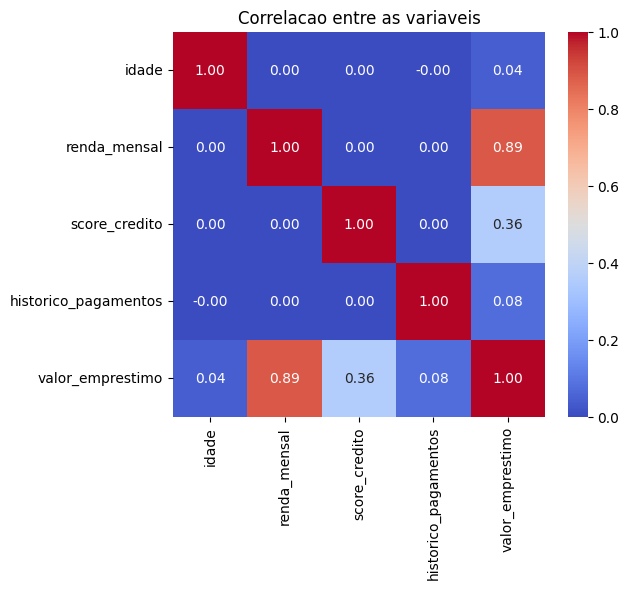

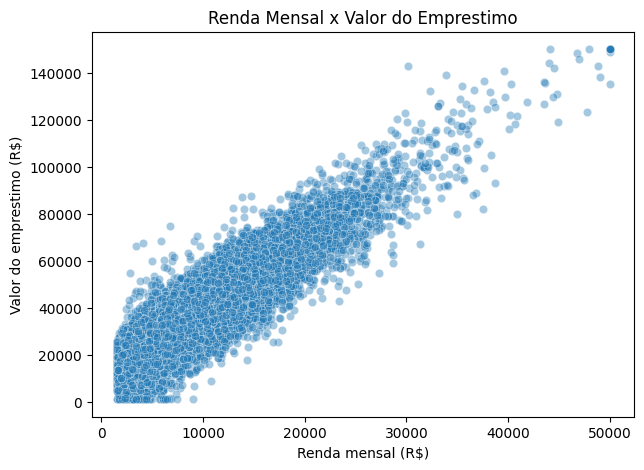

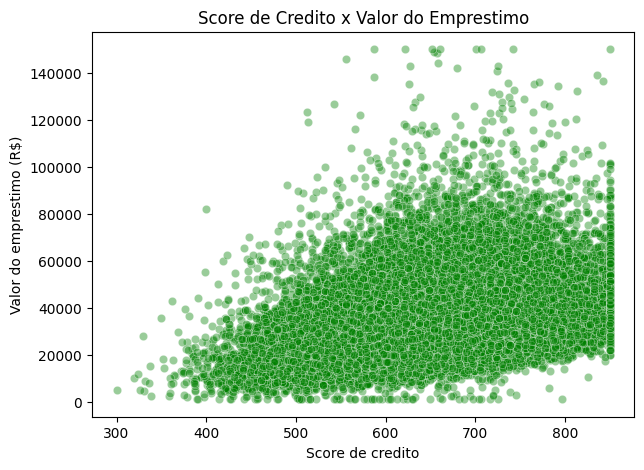


Tamanho do conjunto de treino: 40000 registros
Tamanho do conjunto de teste: 10000 registros

Modelo treinado com sucesso!
Coeficientes: {'idade': np.float64(54.706245869379785), 'renda_mensal': np.float64(2.828447781502101), 'score_credito': np.float64(60.89056417638436), 'historico_pagamentos': np.float64(98.90728868733869)}
Intercepto: -39439.69237251811

MAE  (Erro Absoluto Medio): R$ 2985.94
RMSE (Raiz do Erro Quadratico Medio): R$ 4014.17
R2   (Coeficiente de Determinacao): 0.9223

Comparacao entre valores reais e previstos (15 primeiros exemplos):
    Valor Real  Valor Previsto    Diferenca
0     22268.46    14806.335657  7462.124343
1     27457.59    29512.492879 -2054.902879
2     25451.04    25840.735547  -389.695547
3     23890.67    21077.522905  2813.147095
4     27754.95    27919.314046  -164.364046
5     12544.92    14530.910394 -1985.990394
6     28759.01    27385.966936  1373.043064
7     46454.49    41011.609092  5442.880908
8     43199.01    36525.087756  6673.92224

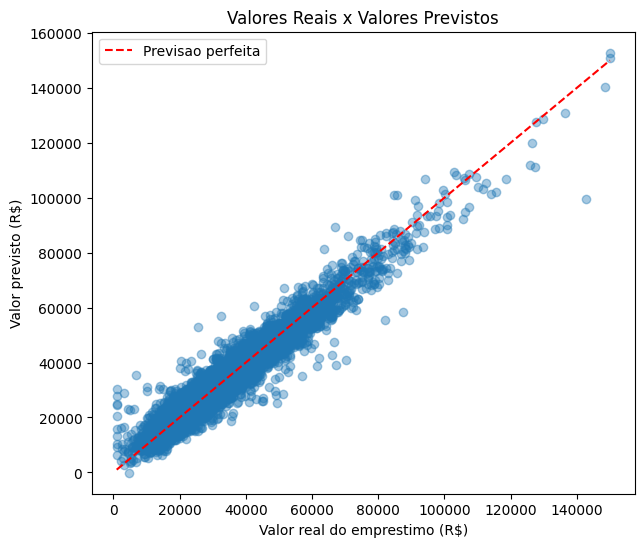


Caracteristicas do novo cliente:
   idade  renda_mensal  score_credito  historico_pagamentos
0     30        8500.0            680                  88.5

Valor de emprestimo previsto: R$ 36402.18


In [ ]:
print("Teste 1 - Inteligência Artificial")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# ETAPA 1 - Carregar os dados

from google.colab import drive
drive.mount('/content/drive')
caminho_csv = '/content/drive/MyDrive/base_credito.csv'

df = pd.read_csv(caminho_csv)

print("Tabela carregada (10 primeiras linhas):")
print(df.head(10))

print(f"\nNumero de linhas: {df.shape[0]}")
print(f"Numero de colunas: {df.shape[1]}")

# ETAPA 2 - Conhecer os dados

print("\nTipos de dados de cada coluna:")
df.info()

print("\nEstatisticas descritivas:")
print(df.describe())

print("\nValores ausentes por coluna:")
print(df.isnull().sum())

# ETAPA 3 - Analisar os dados


plt.figure(figsize=(6, 5))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlacao entre as variaveis')
plt.show()

plt.figure(figsize=(7, 5))
sns.scatterplot(data=df, x='renda_mensal', y='valor_emprestimo', alpha=0.4)
plt.title('Renda Mensal x Valor do Emprestimo')
plt.xlabel('Renda mensal (R$)')
plt.ylabel('Valor do emprestimo (R$)')
plt.show()

plt.figure(figsize=(7, 5))
sns.scatterplot(data=df, x='score_credito', y='valor_emprestimo', alpha=0.4, color='green')
plt.title('Score de Credito x Valor do Emprestimo')
plt.xlabel('Score de credito')
plt.ylabel('Valor do emprestimo (R$)')
plt.show()

# ETAPA 4 - Preparar os dados

X = df[['idade', 'renda_mensal', 'score_credito', 'historico_pagamentos']]

y = df['valor_emprestimo']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"\nTamanho do conjunto de treino: {X_train.shape[0]} registros")
print(f"Tamanho do conjunto de teste: {X_test.shape[0]} registros")

# ETAPA 5 - Treinar o modelo

modelo = LinearRegression()

modelo.fit(X_train, y_train)

y_pred = modelo.predict(X_test)

print("\nModelo treinado com sucesso!")
print("Coeficientes:", dict(zip(X.columns, modelo.coef_)))
print("Intercepto:", modelo.intercept_)

# ETAPA 6 - Avaliar o modelo

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"\nMAE  (Erro Absoluto Medio): R$ {mae:.2f}")
print(f"RMSE (Raiz do Erro Quadratico Medio): R$ {rmse:.2f}")
print(f"R2   (Coeficiente de Determinacao): {r2:.4f}")

comparacao = pd.DataFrame({
    'Valor Real': y_test.values,
    'Valor Previsto': y_pred,
    'Diferenca': y_test.values - y_pred
})

print("\nComparacao entre valores reais e previstos (15 primeiros exemplos):")
print(comparacao.head(15))

plt.figure(figsize=(7, 6))
plt.scatter(y_test, y_pred, alpha=0.4)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', label='Previsao perfeita')
plt.xlabel('Valor real do emprestimo (R$)')
plt.ylabel('Valor previsto (R$)')
plt.title('Valores Reais x Valores Previstos')
plt.legend()
plt.show()

# ETAPA 8 - Fazer uma previsao para um novo cliente

novo_cliente = pd.DataFrame({
    'idade': [30],
    'renda_mensal': [8500.00],
    'score_credito': [680],
    'historico_pagamentos': [88.5]
})

print("\nCaracteristicas do novo cliente:")
print(novo_cliente)

previsao_novo_cliente = modelo.predict(novo_cliente)
print(f"\nValor de emprestimo previsto: R$ {previsao_novo_cliente[0]:.2f}")

# ETAPA 9 - Conclusao
